# Etapa 2.4 — MLP Training, Evaluation & Comparison

Treina a MLP com PyTorch, compara com os baselines da Etapa 1 e analisa o trade-off de custo FP vs FN.

In [1]:
import logging
import sys
sys.path.insert(0, '..')

import mlflow
import mlflow.pytorch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, f1_score, roc_auc_score, precision_score, recall_score

from src.model import ChurnMLP
from src.train import train_model, set_seeds
from src.preprocessing import load_and_split
from src.evaluate import evaluate, cost_analysis

logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s %(name)s — %(message)s')
set_seeds(42)

## 1. Carregar e pré-processar dados

In [2]:
DATA_PATH = '../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv'
X_train, X_test, y_train, y_test, preprocessor = load_and_split(DATA_PATH)
print(f'Train: {X_train.shape}, Test: {X_test.shape}, Churn rate: {y_train.mean():.2%}')

Train: (5634, 46), Test: (1409, 46), Churn rate: 26.54%


## 2. Treinar MLP com MLflow tracking

In [3]:
INPUT_DIM = X_train.shape[1]
CONFIG = {
    'epochs': 100,
    'batch_size': 64,
    'lr': 1e-3,
    'patience': 10,
}
HIDDEN_DIMS = [64, 32]
DROPOUT = 0.3

mlflow.set_experiment('churn-mlp')

with mlflow.start_run(run_name='mlp-baseline') as run:
    mlflow.log_params({**CONFIG, 'hidden_dims': str(HIDDEN_DIMS), 'dropout': DROPOUT})

    model = ChurnMLP(input_dim=INPUT_DIM, hidden_dims=HIDDEN_DIMS, dropout=DROPOUT)
    model, history = train_model(model, X_train, y_train, X_test, y_test, CONFIG)

    metrics = evaluate(model, X_test, y_test)
    mlflow.log_metrics(metrics)
    mlflow.pytorch.log_model(model, 'model')

    mlp_run_id = run.info.run_id
    print('MLflow run_id:', mlp_run_id)
    print('Métricas MLP:', metrics)

2026/04/16 20:37:02 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/04/16 20:37:02 INFO mlflow.store.db.utils: Updating database tables


2026/04/16 20:37:04 INFO mlflow.tracking.fluent: Experiment with name 'churn-mlp' does not exist. Creating a new experiment.


2026/04/16 20:37:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/16 20:37:15 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


MLflow run_id: a6bbba5363c94fbfa4570a45ef8f8b83
Métricas MLP: {'f1': 0.6270136307311028, 'roc_auc': 0.8440349789454649, 'precision': 0.5842956120092379, 'recall': 0.6764705882352942}


## 3. Curva de loss (treino vs validação)

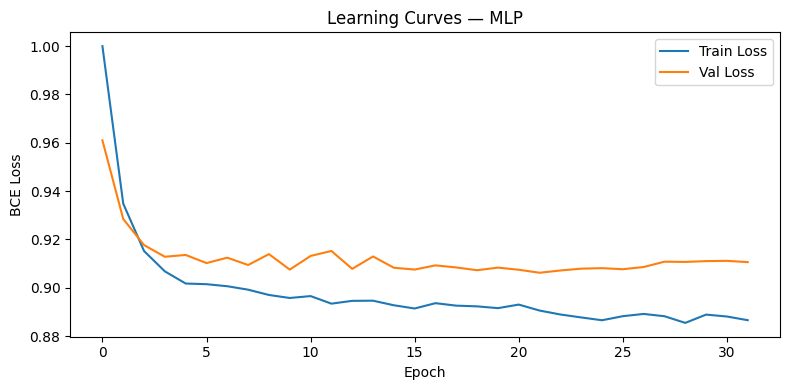

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history['train'], label='Train Loss')
ax.plot(history['val'],   label='Val Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE Loss')
ax.set_title('Learning Curves — MLP')
ax.legend()
plt.tight_layout()
plt.savefig('../docs/loss_curve.png', dpi=100)
plt.show()

## 4. Treinar baselines para comparação

In [5]:
def sklearn_metrics(clf, X_tr, y_tr, X_te, y_te, run_name):
    """Fit, predict and log a sklearn classifier, returning its metrics dict."""
    clf.fit(X_tr, y_tr)
    preds = clf.predict(X_te)
    probs = clf.predict_proba(X_te)[:, 1] if hasattr(clf, 'predict_proba') else preds.astype(float)
    m = {
        'f1':        f1_score(y_te, preds),
        'roc_auc':   roc_auc_score(y_te, probs),
        'precision': precision_score(y_te, preds),
        'recall':    recall_score(y_te, preds),
    }
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params({'model': run_name})
        mlflow.log_metrics(m)
    return run_name, m

baseline_results = {}

_, m = sklearn_metrics(
    DummyClassifier(strategy='most_frequent'), X_train, y_train, X_test, y_test, 'dummy'
)
baseline_results['Dummy'] = m

_, m = sklearn_metrics(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    X_train, y_train, X_test, y_test, 'logistic-regression'
)
baseline_results['LogisticRegression'] = m

print(baseline_results)

{'Dummy': {'f1': 0.0, 'roc_auc': 0.5, 'precision': 0.0, 'recall': 0.0}, 'LogisticRegression': {'f1': 0.6167023554603854, 'roc_auc': 0.8447299077733861, 'precision': 0.5142857142857142, 'recall': 0.7700534759358288}}


/root/MLET/tech-challenge/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## 5. Tabela comparativa de modelos

In [6]:
all_results = {**baseline_results, 'MLP (PyTorch)': metrics}
comparison_df = pd.DataFrame(all_results).T.round(4)
comparison_df.index.name = 'Model'
comparison_df

,f1,roc_auc,precision,recall
Model,,,,
Dummy,0.0000,0.5000,0.0000,0.0000
LogisticRegression,0.6167,0.8447,0.5143,0.7701
MLP (PyTorch),0.6270,0.8440,0.5843,0.6765


## 6. Matriz de confusão — MLP

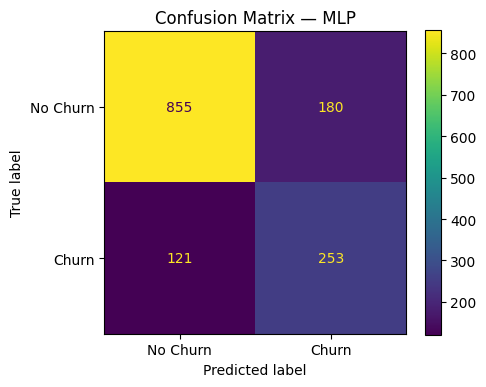

In [7]:
model.eval()
with torch.no_grad():
    probs_mlp = model(torch.tensor(X_test, dtype=torch.float32)).squeeze().numpy()
preds_mlp = (probs_mlp >= 0.5).astype(int)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, preds_mlp, display_labels=['No Churn', 'Churn'], ax=ax)
ax.set_title('Confusion Matrix — MLP')
plt.tight_layout()
plt.savefig('../docs/confusion_matrix.png', dpi=100)
plt.show()

## 7. Análise de trade-off FP vs FN (custo de negócio)

In [8]:
# Custo de um FN (cliente perdido sem intervenção): R$500
# Custo de um FP (campanha de retenção desnecessária): R$50
COST_FP = 50.0
COST_FN = 500.0

lr_clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_clf.fit(X_train, y_train)
preds_lr = lr_clf.predict(X_test)

cost_mlp = cost_analysis(y_test, preds_mlp, COST_FP, COST_FN)
cost_lr  = cost_analysis(y_test, preds_lr,  COST_FP, COST_FN)

cost_df = pd.DataFrame({'MLP': cost_mlp, 'LogisticRegression': cost_lr}).T
cost_df['total_cost'] = cost_df['total_cost'].map('R$ {:,.0f}'.format)
cost_df

,fp_count,fn_count,total_cost
MLP,180.0,121.0,"R$ 69,500"
LogisticRegression,272.0,86.0,"R$ 56,600"


## 8. Análise de threshold ótimo (FP/FN trade-off visual)

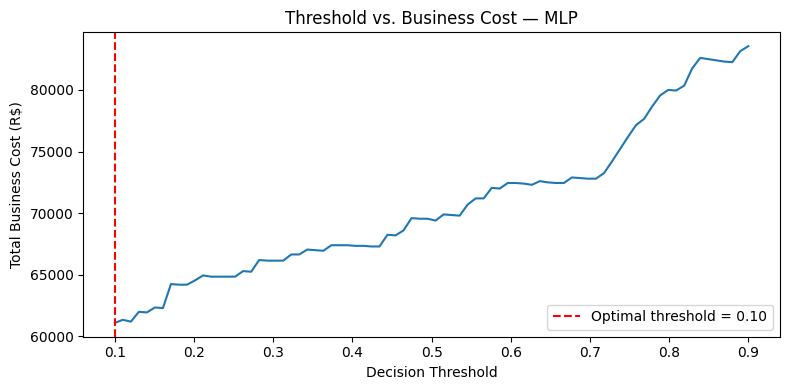

Threshold ótimo: 0.10 — Custo mínimo: R$ 61,100


In [9]:
thresholds = np.linspace(0.1, 0.9, 80)
costs = []
for t in thresholds:
    p = (probs_mlp >= t).astype(int)
    c = cost_analysis(y_test, p, COST_FP, COST_FN)
    costs.append(c['total_cost'])

best_t = thresholds[np.argmin(costs)]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, costs)
ax.axvline(best_t, color='red', linestyle='--', label=f'Optimal threshold = {best_t:.2f}')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Total Business Cost (R$)')
ax.set_title('Threshold vs. Business Cost — MLP')
ax.legend()
plt.tight_layout()
plt.savefig('../docs/threshold_cost.png', dpi=100)
plt.show()
print(f'Threshold ótimo: {best_t:.2f} — Custo mínimo: R$ {min(costs):,.0f}')